In [25]:
import tensorflow as tf
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import os
import matplotlib
from helper import *
import seaborn as sns


import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import keras
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization
from scipy.stats import spearmanr

%matplotlib inline

In [17]:
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data") # Load data
test_df = pd.read_csv(path + "/test_FD004.txt") # Look at test df

# Print all files in downloaded dataset
print("All files in dataset: ")
os.listdir(path)

All files in dataset: 


['Damage Propagation Modeling.pdf',
 'train_FD001.txt',
 'train_FD003.txt',
 'RUL_FD004.txt',
 'train_FD002.txt',
 'RUL_FD001.txt',
 'RUL_FD003.txt',
 'RUL_FD002.txt',
 'train_FD004.txt',
 'test_FD003.txt',
 'test_FD002.txt',
 'test_FD001.txt',
 'test_FD004.txt',
 'readme.txt']

Note that the RUL values are only for the test data set.

In [18]:
# Print head of original dataset
print(test_df.head())

  1 1 20.0072 0.7000 100.0 491.19 606.67 1481.04 1227.81 9.35 13.60 332.52 2323.67 8704.98 1.07 43.83 313.03 2387.78 8048.98 9.2229 0.02 362 2324 100.00 24.31 14.7007  
0  1 2 24.9984 0.6200 60.0 462.54 536.22 1256.17 ...                                                                                                                    
1  1 3 42.0000 0.8420 100.0 445.00 549.23 1340.13...                                                                                                                    
2  1 4 42.0035 0.8402 100.0 445.00 549.19 1339.70...                                                                                                                    
3  1 5 35.0079 0.8400 100.0 449.44 555.10 1353.04...                                                                                                                    
4  1 6 25.0010 0.6203 60.0 462.54 536.40 1255.38 ...                                                                                                       

In [19]:
# Add column names to data set
df_train = pd.read_csv(os.path.join(path, 'train_FD004.txt'), sep=' ', header=None)
df_test = pd.read_csv(os.path.join(path, 'test_FD004.txt'), sep=' ', header=None)
col_names = ['Unit', 'Cycle Time'] + [f'Operational Setting {_+1}' for _ in range(3)] + [f'Sensor {_+1}' for _ in range(23)]

df_test.columns = col_names
df_train.columns = col_names

print(df_train.head()) # Print new head

   Unit  Cycle Time  Operational Setting 1  Operational Setting 2  \
0     1           1                42.0049                 0.8400   
1     1           2                20.0020                 0.7002   
2     1           3                42.0038                 0.8409   
3     1           4                42.0000                 0.8400   
4     1           5                25.0063                 0.6207   

   Operational Setting 3  Sensor 1  Sensor 2  Sensor 3  Sensor 4  Sensor 5  \
0                  100.0    445.00    549.68   1343.43   1112.93      3.91   
1                  100.0    491.19    606.07   1477.61   1237.50      9.35   
2                  100.0    445.00    548.95   1343.12   1117.05      3.91   
3                  100.0    445.00    548.70   1341.24   1118.03      3.91   
4                   60.0    462.54    536.10   1255.23   1033.59      7.05   

   ...  Sensor 14  Sensor 15  Sensor 16  Sensor 17  Sensor 18  Sensor 19  \
0  ...    8074.83     9.3335       0.02 

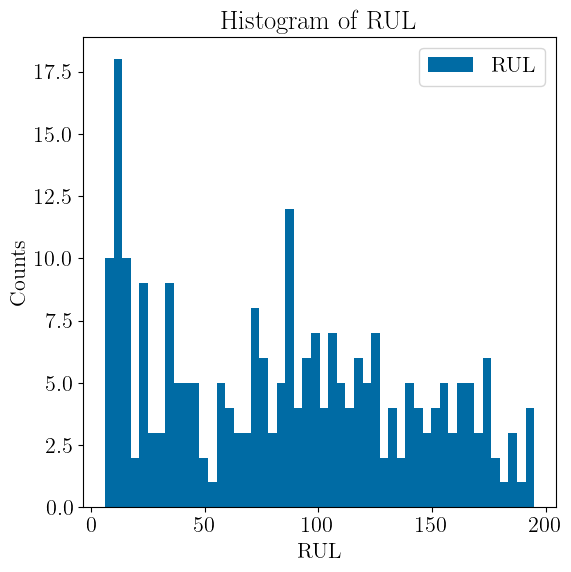

In [20]:
# Make a histogram of the RULs
df_RUL = pd.read_csv(os.path.join(path, 'RUL_FD004.txt'), sep=' ', header=None)
df_RUL.columns = ["RUL", "null"] # Investigate why I need this null col

RUL_fig = data_vis_hist(df_RUL, f"RUL", bins = 50)

Training on ~30 cycles looks good for this.

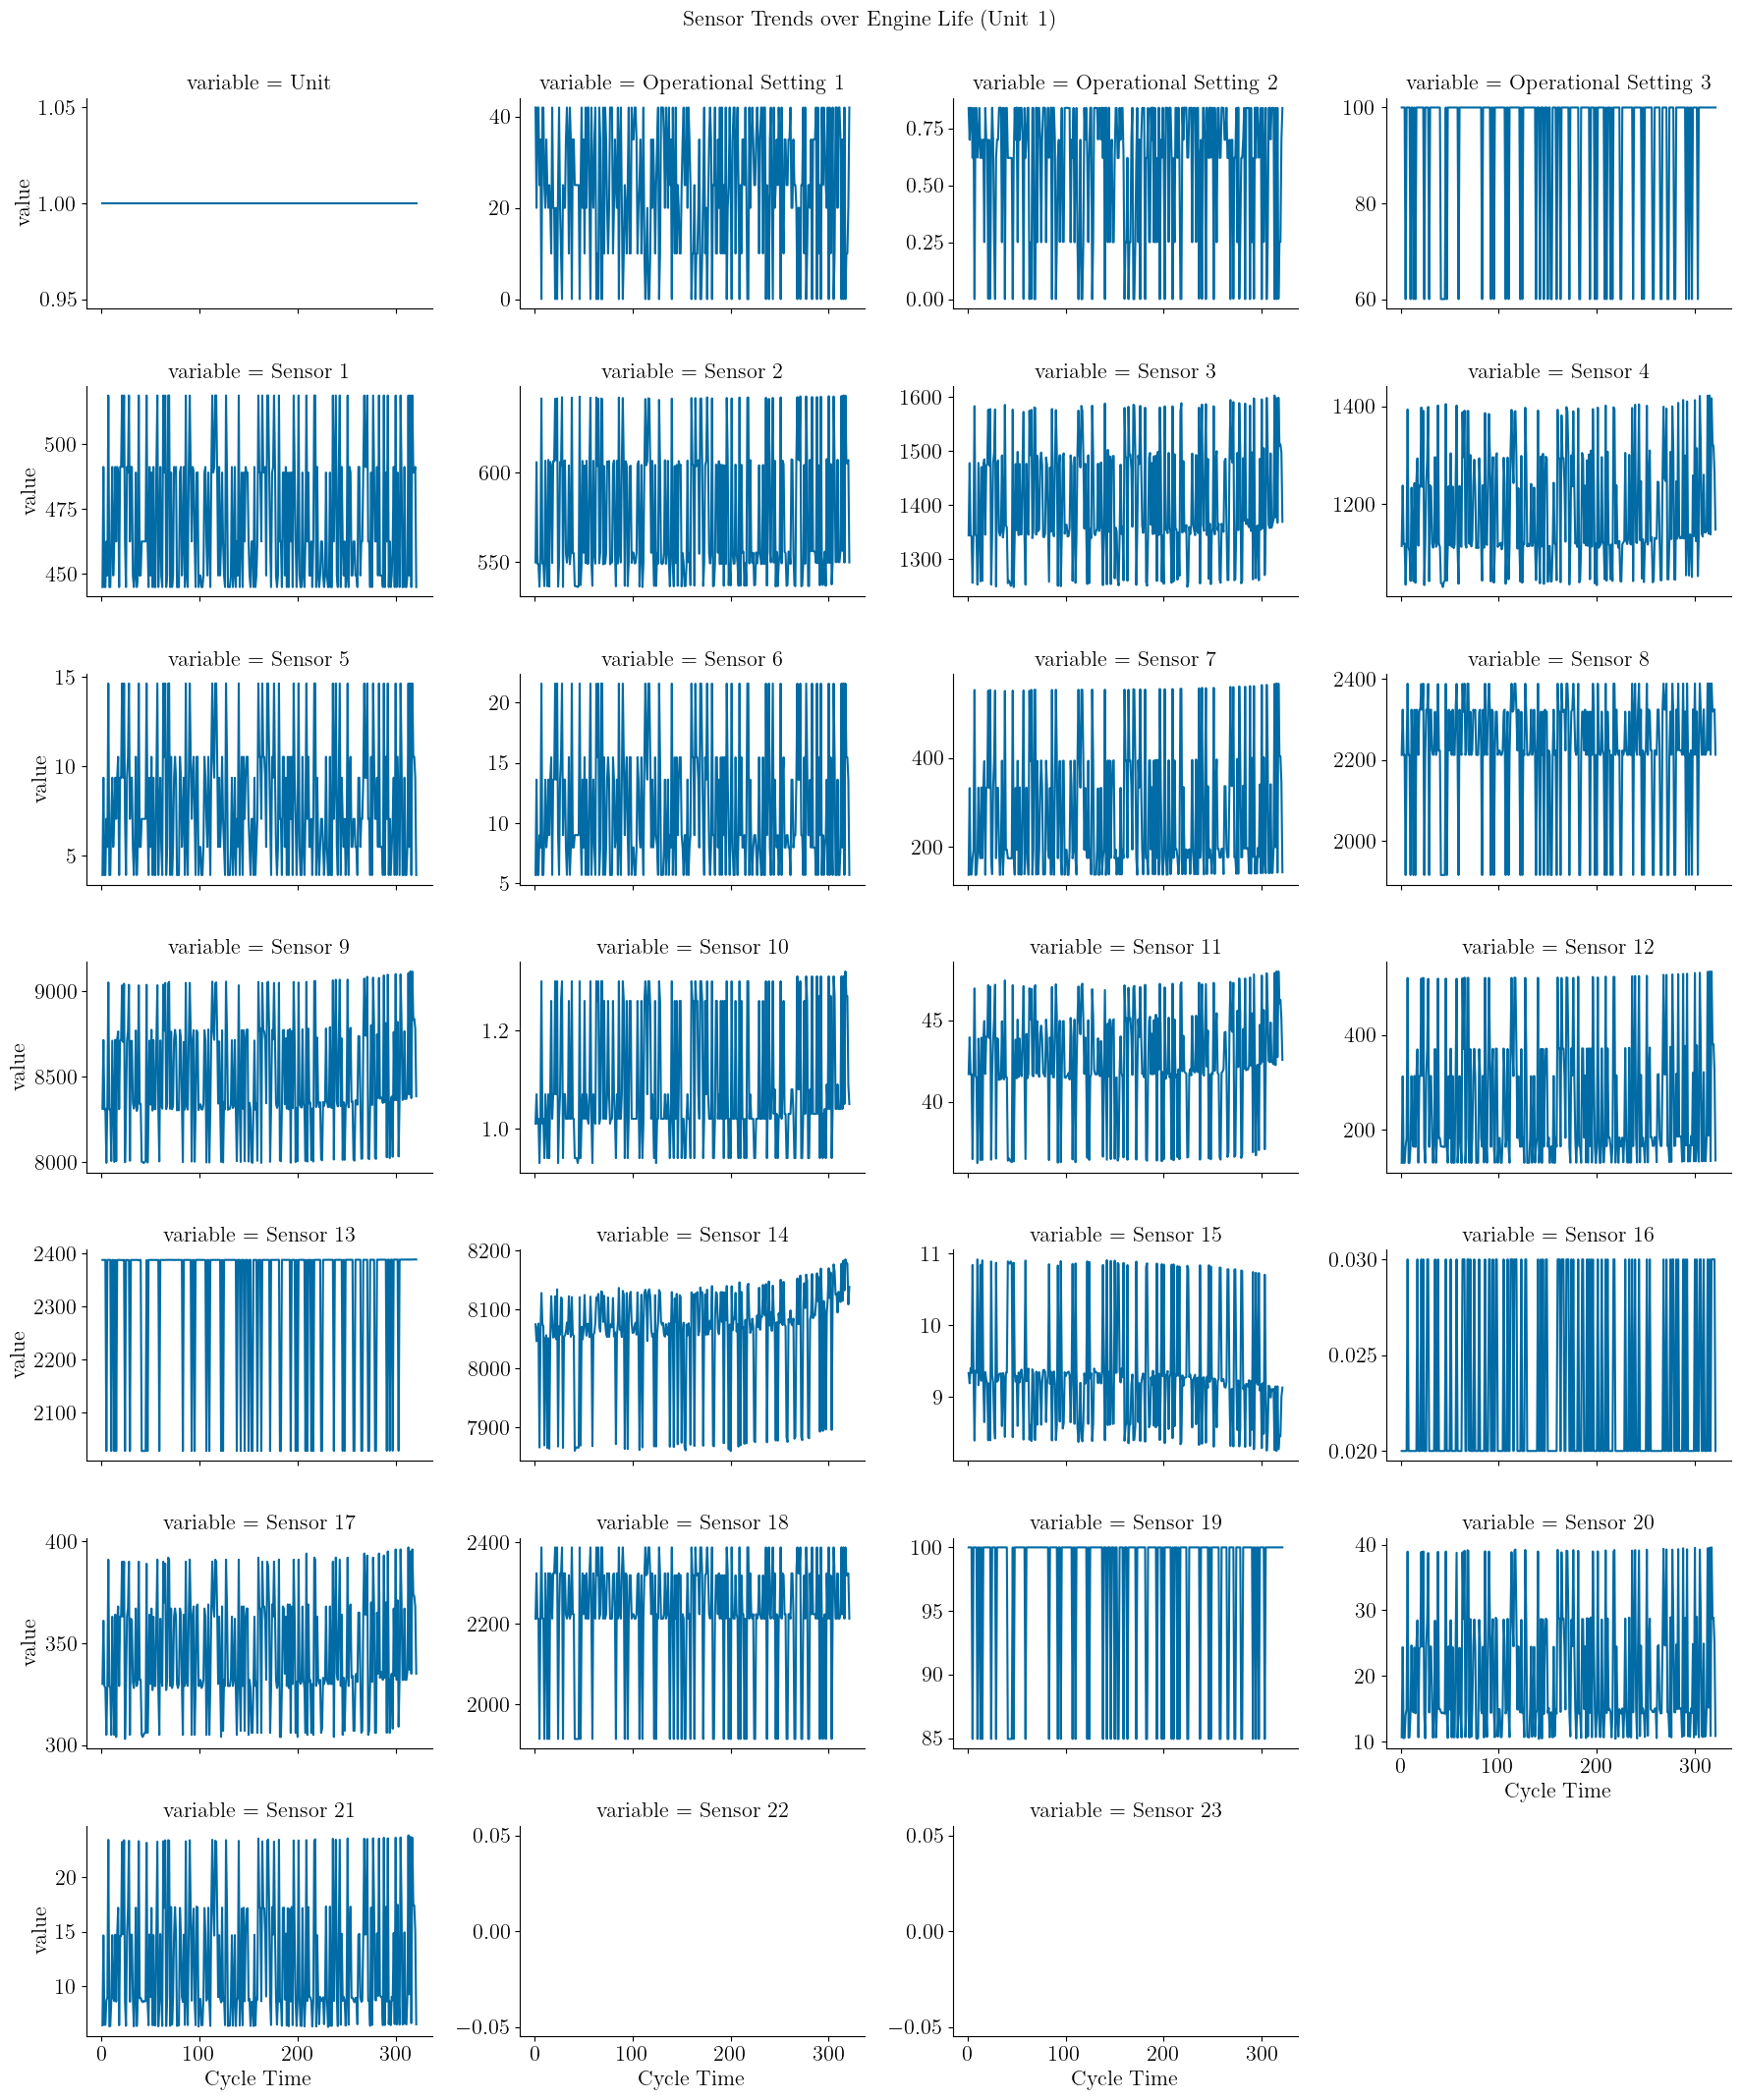

In [21]:
unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Cycle Time', value_vars=col_names)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Cycle Time", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

Sensors to drop: 1, 5, 6, 10, 16, 17, 18, 19, (22, 23?)

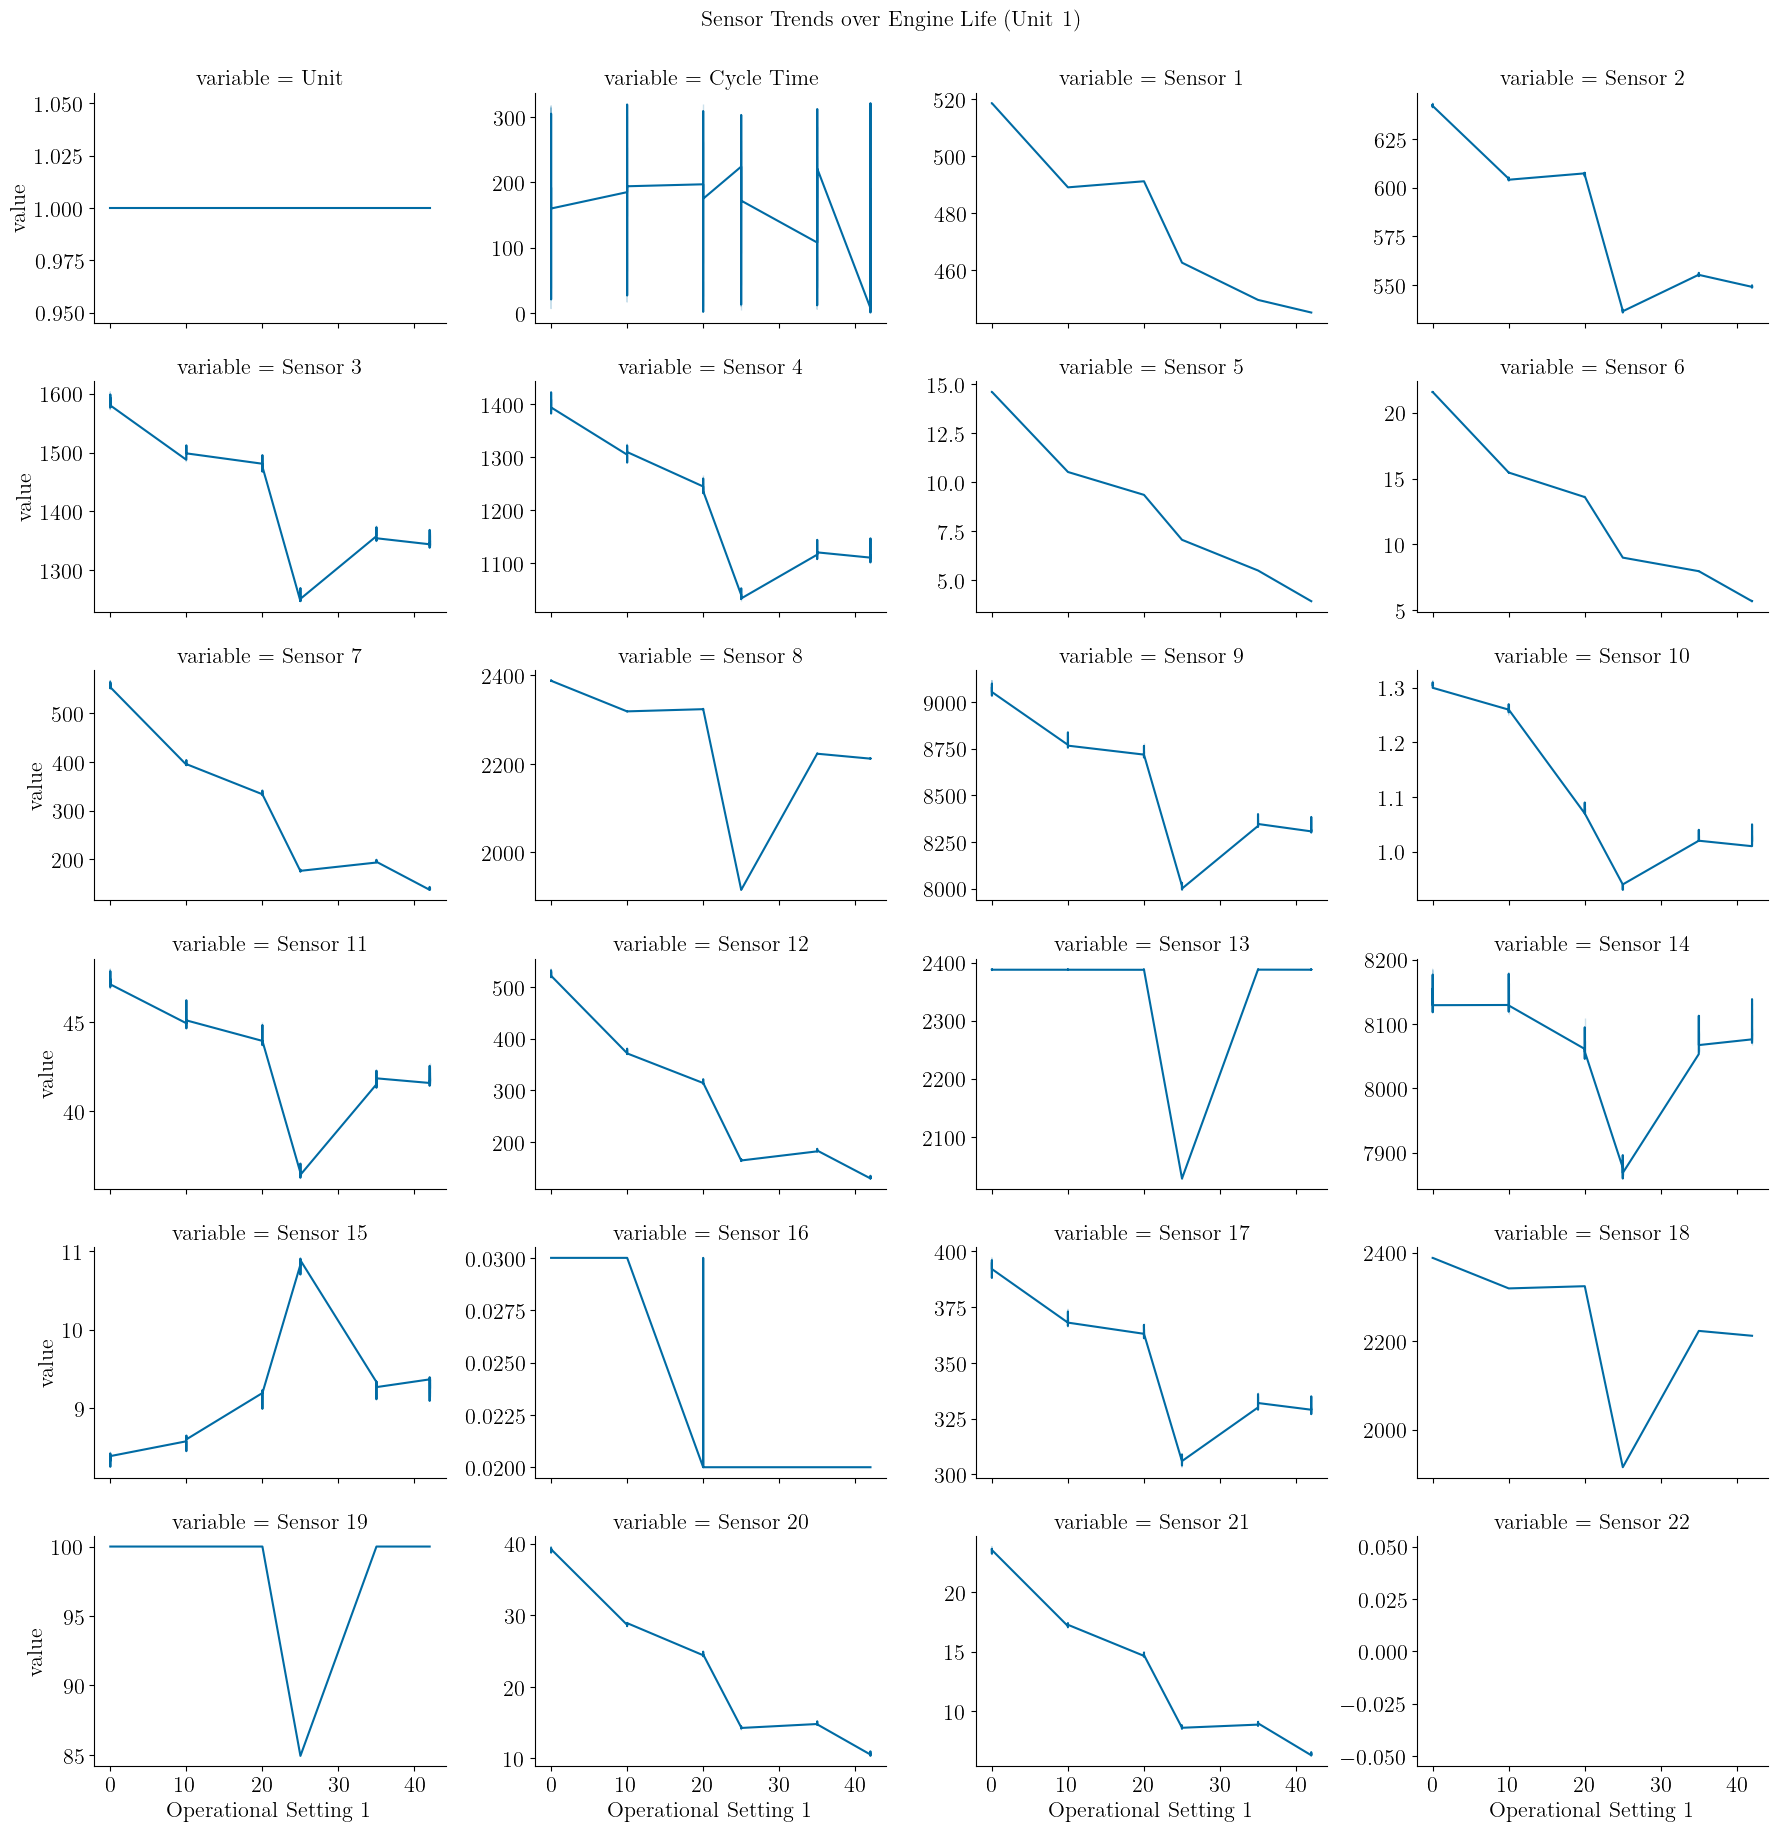

In [22]:
# Check to see if operational settings correlate to something
# Operational Setting 1

unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Operational Setting 1', value_vars=relevant_sensors)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Operational Setting 1", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

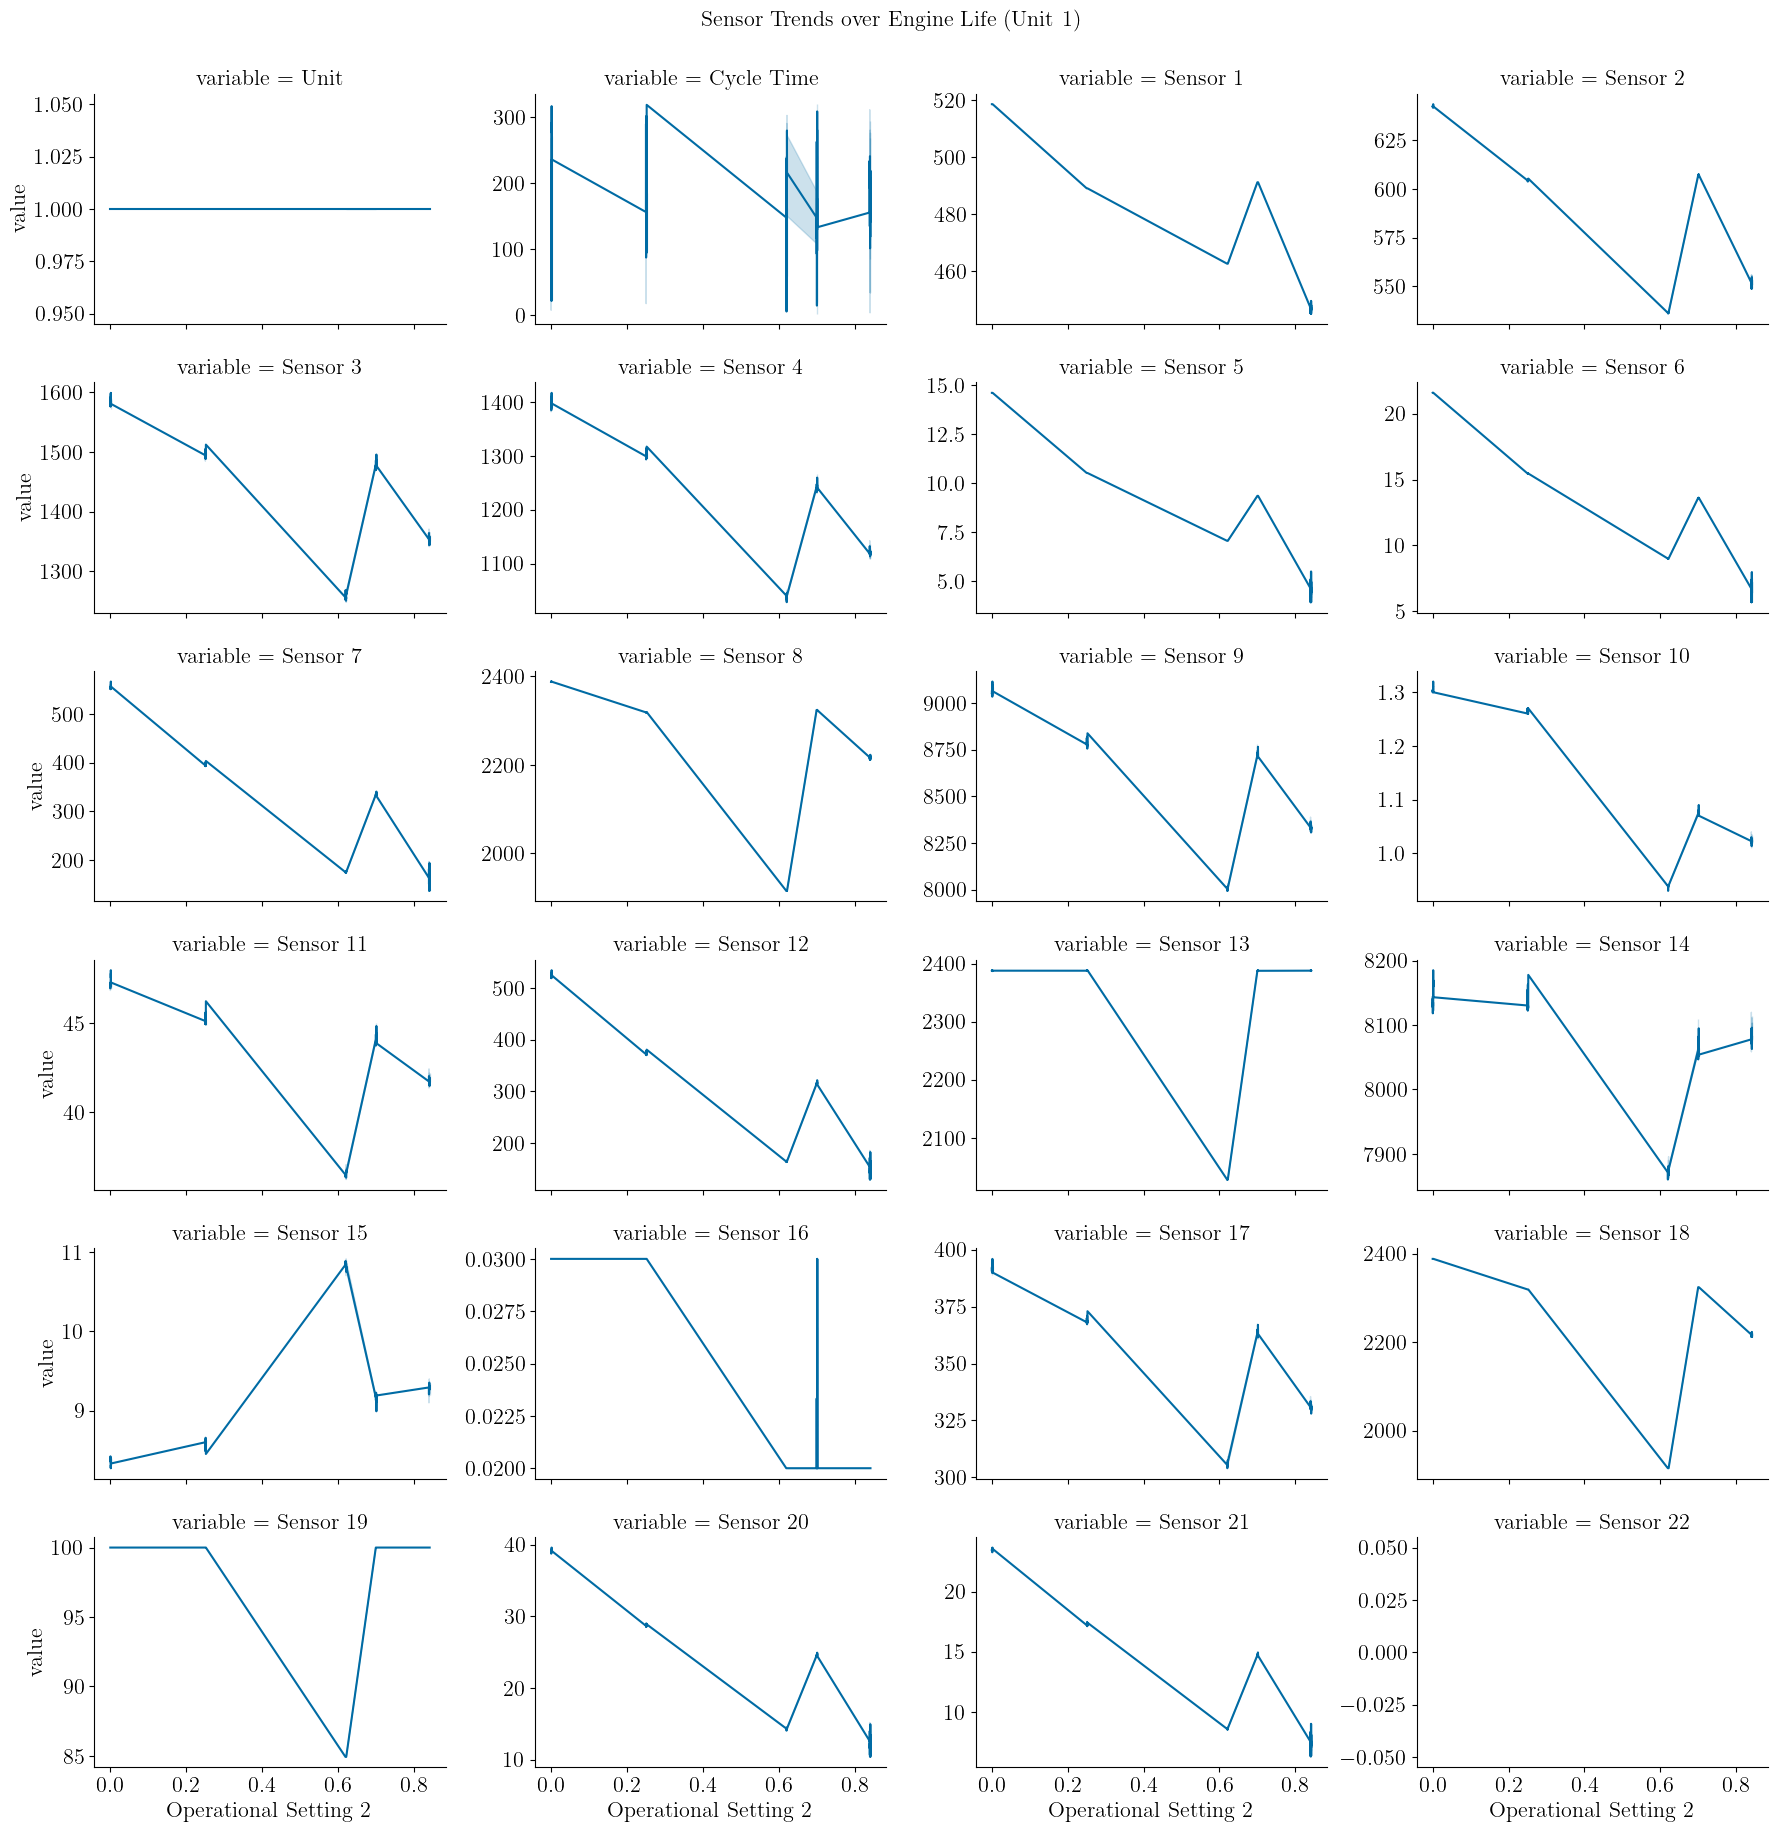

In [23]:
# Operational Setting 2

unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Operational Setting 2', value_vars=relevant_sensors)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Operational Setting 2", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()

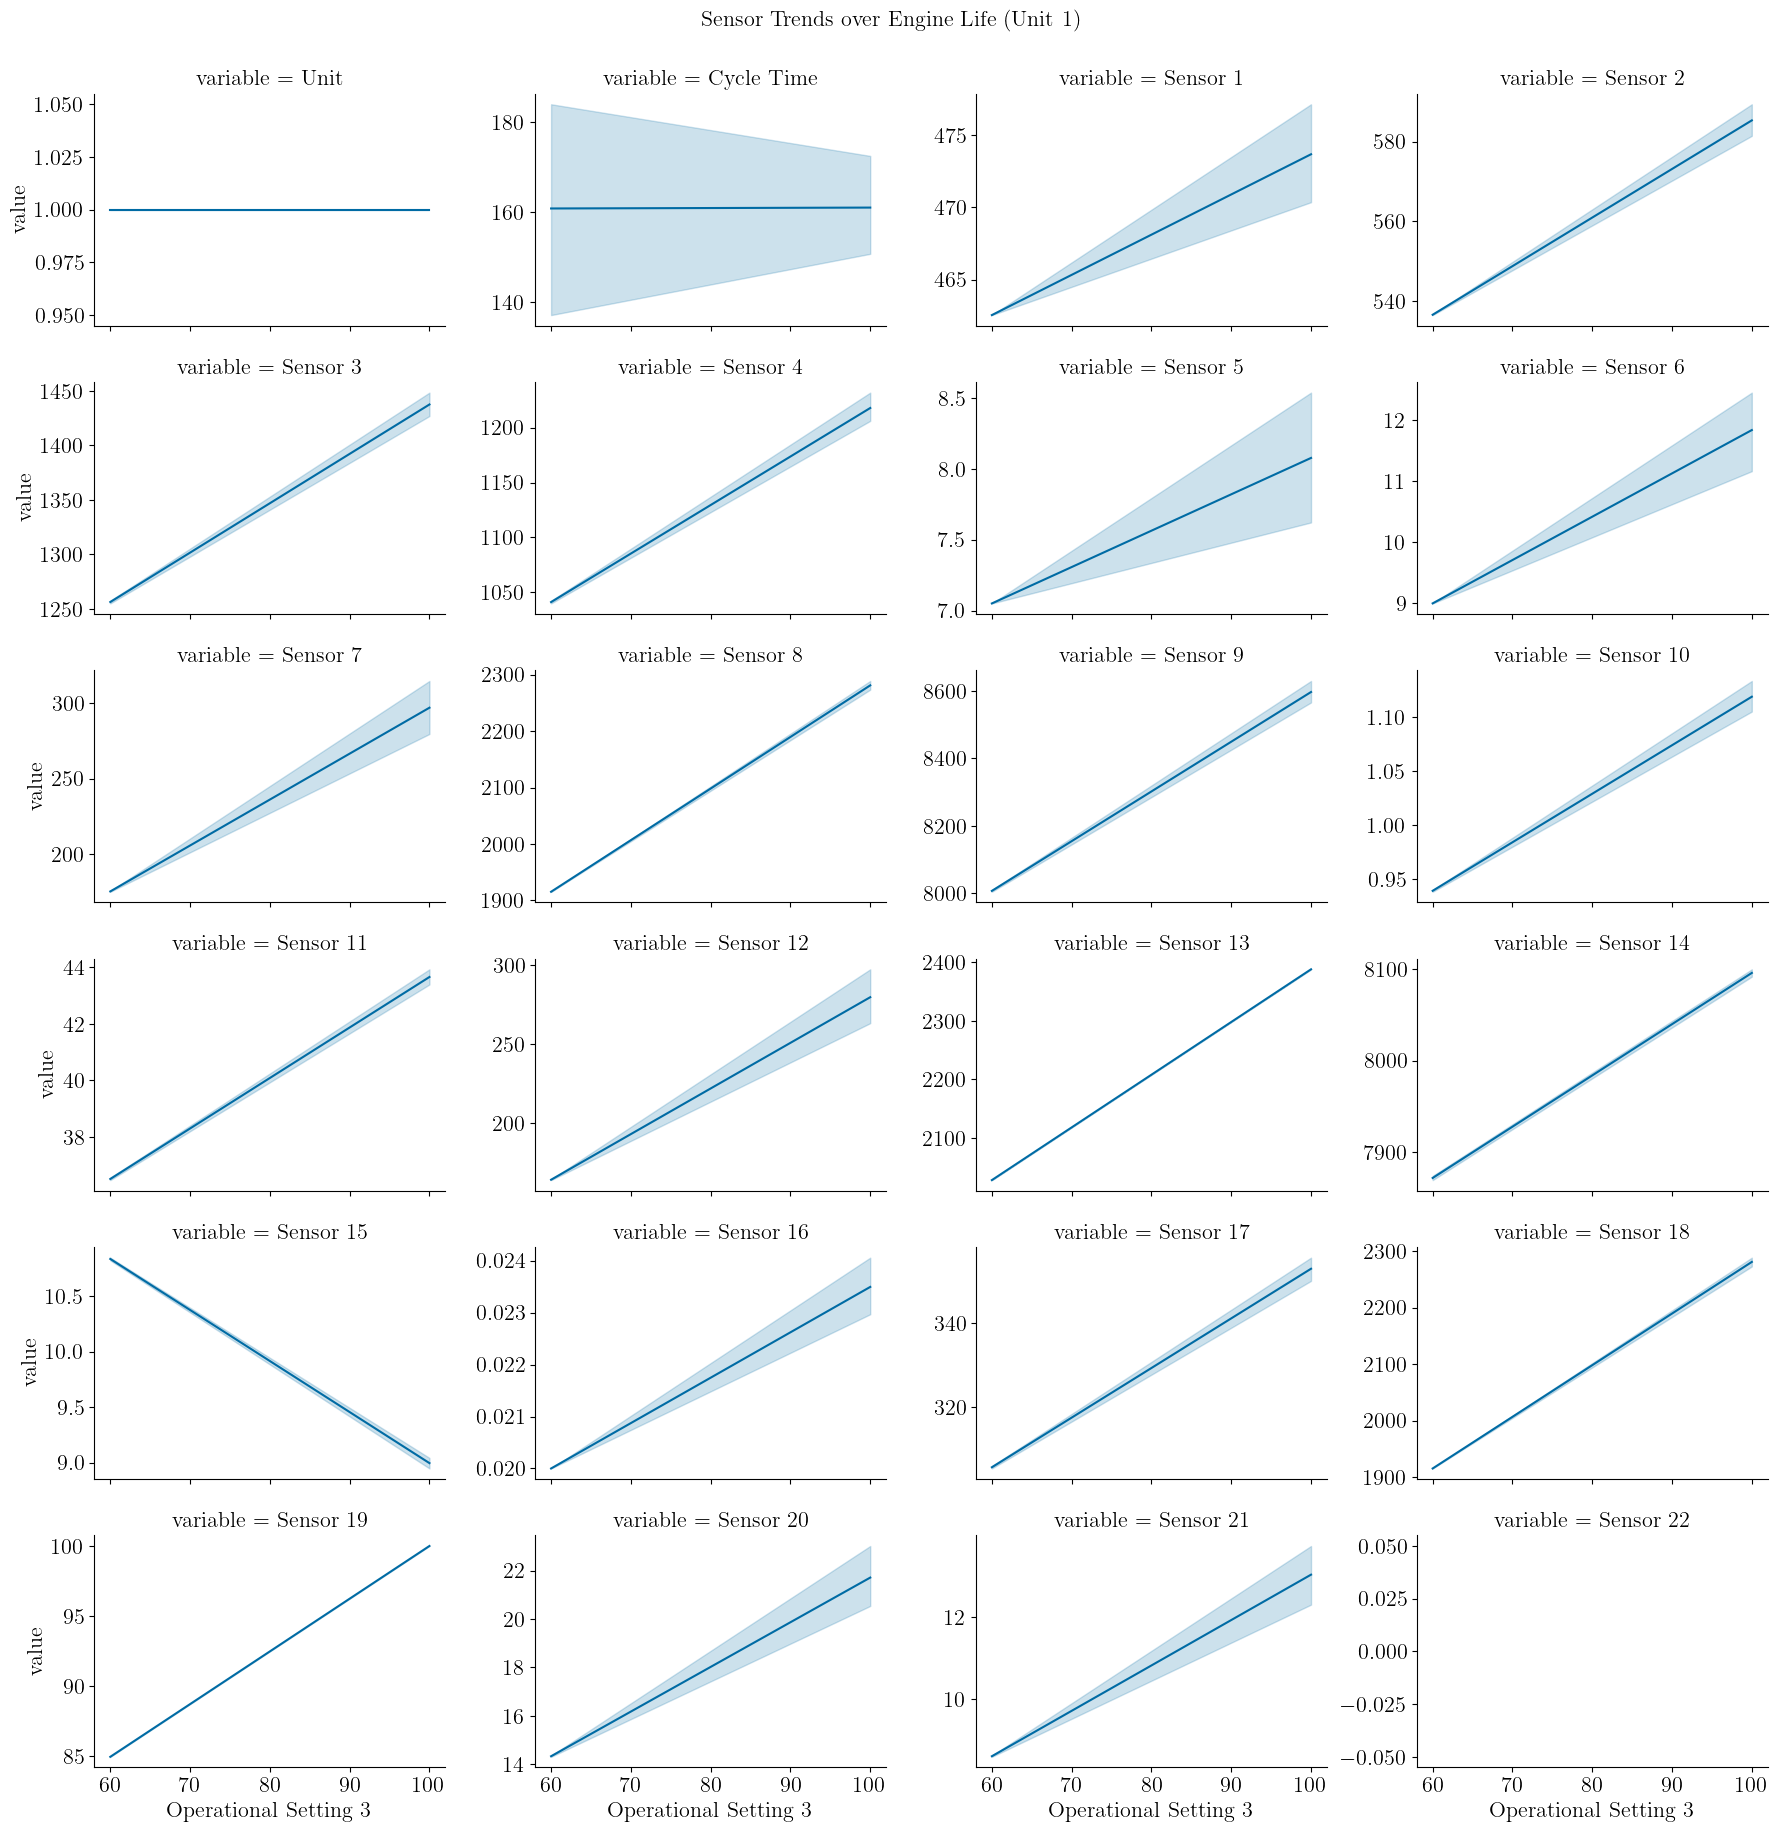

In [24]:
# Operational Setting 3

unit_data = df_train[df_train['Unit'] == 1]
relevant_sensors = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(22)]
plot_data = unit_data.melt(id_vars='Operational Setting 3', value_vars=relevant_sensors)

# Create a grid of plots
g = sns.FacetGrid(plot_data, col="variable", col_wrap=4, sharey=False, aspect=1.5)
g.map(sns.lineplot, "Operational Setting 3", "value")

# Add a title and adjust layout
g.fig.suptitle('Sensor Trends over Engine Life (Unit 1)', y=1.02, fontsize=16)
plt.show()